In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [6]:
df = pd.read_csv('/content/train.csv',usecols = ['Age','Fare','SibSp','Parch','Survived'])

In [7]:
df['Famliy'] = df['SibSp'] + df['Parch']

In [8]:
df.drop(['SibSp','Parch'],axis = 1,inplace = True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
 3   Famliy    891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [10]:
df.isnull().mean()

,0
Survived,0.000000
Age,0.198653
Fare,0.000000
Famliy,0.000000


In [11]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [13]:
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [14]:
x_train.isnull().mean()

,0
Age,0.196629
Fare,0.000000
Famliy,0.000000


In [15]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()

mean_age,median_age

(np.float64(29.498846153846156), 28.0)

In [16]:
x_train['age_mean'] = x_train['Age'].fillna(mean_age)
x_train['age_median'] = x_train['Age'].fillna(median_age)

In [17]:
x_train.sample(5)

,Age,Fare,Famliy,age_mean,age_median
432,42.0,26.0000,1,42.000000,42.0
420,NaN,7.8958,0,29.498846,28.0
664,20.0,7.9250,1,20.000000,20.0
364,NaN,15.5000,1,29.498846,28.0
799,30.0,24.1500,2,30.000000,30.0


In [18]:
print('Original Age Variable varieance',x_train['Age'].var())
print('Age varieance after mean imputation',x_train['age_mean'].var())
print('Age varieance after median imputation',x_train['age_median'].var())

Original Age Variable varieance 210.2517072477438
Age varieance after mean imputation 168.8519336687225
Age varieance after median imputation 169.20731007048096


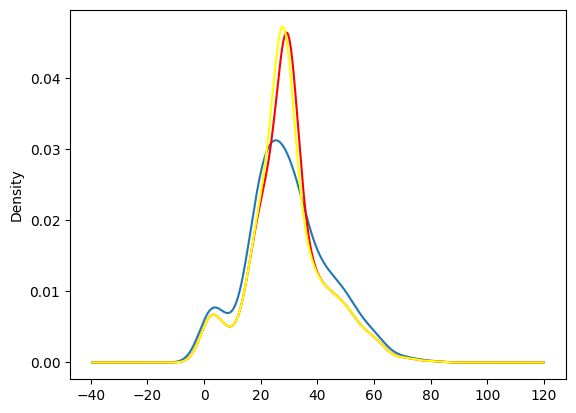

In [19]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Original variable Distribution
x_train['Age'].plot(kind = 'kde',ax = ax)

# Variable imputed with mean
x_train['age_mean'].plot(kind = 'kde',ax = ax,color = 'red')

# Variable imputed with median
x_train['age_median'].plot(kind = 'kde',ax = ax,color = 'yellow')

plt.show()